# Proyek Akhir: Menyelesaikan Permasalahan Jaya Jaya Institut

- Nama: Aflaha Setyaningrum
- Email: setyaaflaha@gmail.com
- Id Dicoding: aflahasetyaningrum

## Persiapan
Jaya Jaya Institut menghadapi tingginya angka dropout siswa yang berdampak pada reputasi dan kualitas pendidikan.

Tujuan dari proyek ini adalah:
1. Mengidentifikasi faktor utama penyebab dropout
2. Membangun model prediksi
3. Memberikan rekomendasi berbasis data

### Menyiapkan library yang dibutuhkan

Pada tahap ini dilakukan import library yang digunakan untuk proses analisis data, visualisasi, preprocessing, serta pembuatan model machine learning.

In [36]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Menyiapkan data yang akan diguankan

In [37]:
df = pd.read_csv('data/students.csv')
df.head()
df.shape

(4424, 1)

Dataset yang digunakan berisi informasi terkait performa siswa di Jaya Jaya Institut yang akan digunakan untuk memprediksi kemungkinan dropout.

## Data Understanding

Informasi dataset

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        Non-Null Count  Dtype 
---  ------         

Dataset terdiri dari X baris dan Y kolom dengan beberapa tipe data seperti numerik dan kategorikal yang akan diproses lebih lanjut.

Statistik deskriptif

In [39]:
df.describe()

,Marital_status;Application_mode;Application_order;Course;Daytime_evening_attendance;Previous_qualification;Previous_qualification_grade;Nacionality;Mothers_qualification;Fathers_qualification;Mothers_occupation;Fathers_occupation;Admission_grade;Displaced;Educational_special_needs;Debtor;Tuition_fees_up_to_date;Gender;Scholarship_holder;Age_at_enrollment;International;Curricular_units_1st_sem_credited;Curricular_units_1st_sem_enrolled;Curricular_units_1st_sem_evaluations;Curricular_units_1st_sem_approved;Curricular_units_1st_sem_grade;Curricular_units_1st_sem_without_evaluations;Curricular_units_2nd_sem_credited;Curricular_units_2nd_sem_enrolled;Curricular_units_2nd_sem_evaluations;Curricular_units_2nd_sem_approved;Curricular_units_2nd_sem_grade;Curricular_units_2nd_sem_without_evaluations;Unemployment_rate;Inflation_rate;GDP;Status
count,4424
unique,4424
top,1;17;5;171;1;1;122.0;1;19;12;5;9;127.3;1;0;0;1...
freq,1


Cek missing values

In [40]:
df.isnull().sum()

Marital_status;Application_mode;Application_order;Course;Daytime_evening_attendance;Previous_qualification;Previous_qualification_grade;Nacionality;Mothers_qualification;Fathers_qualification;Mothers_occupation;Fathers_occupation;Admission_grade;Displaced;Educational_special_needs;Debtor;Tuition_fees_up_to_date;Gender;Scholarship_holder;Age_at_enrollment;International;Curricular_units_1st_sem_credited;Curricular_units_1st_sem_enrolled;Curricular_units_1st_sem_evaluations;Curricular_units_1st_sem_approved;Curricular_units_1st_sem_grade;Curricular_units_1st_sem_without_evaluations;Curricular_units_2nd_sem_credited;Curricular_units_2nd_sem_enrolled;Curricular_units_2nd_sem_evaluations;Curricular_units_2nd_sem_approved;Curricular_units_2nd_sem_grade;Curricular_units_2nd_sem_without_evaluations;Unemployment_rate;Inflation_rate;GDP;Status    0
dtype: int64

Tidak terdapat missing values / terdapat beberapa missing values pada kolom tertentu yang perlu ditangani pada tahap preprocessing.

Cek distribusi target

In [41]:
df = pd.read_csv('data/students.csv', sep=';')
df.columns = df.columns.str.strip()

In [42]:
print(df.columns)

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

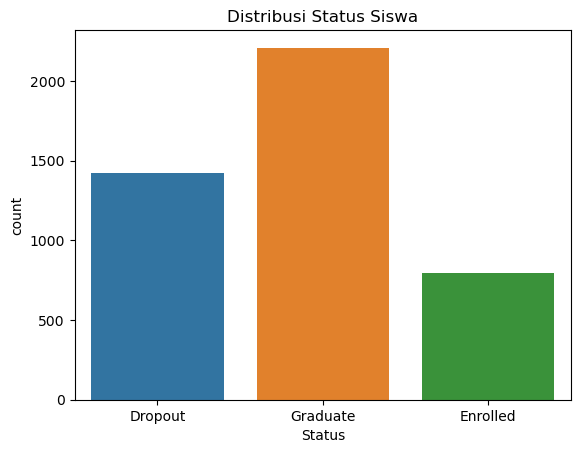

In [43]:
sns.countplot(x='Status', data=df)
plt.title("Distribusi Status Siswa")
plt.show()

Korelasi antar fitur

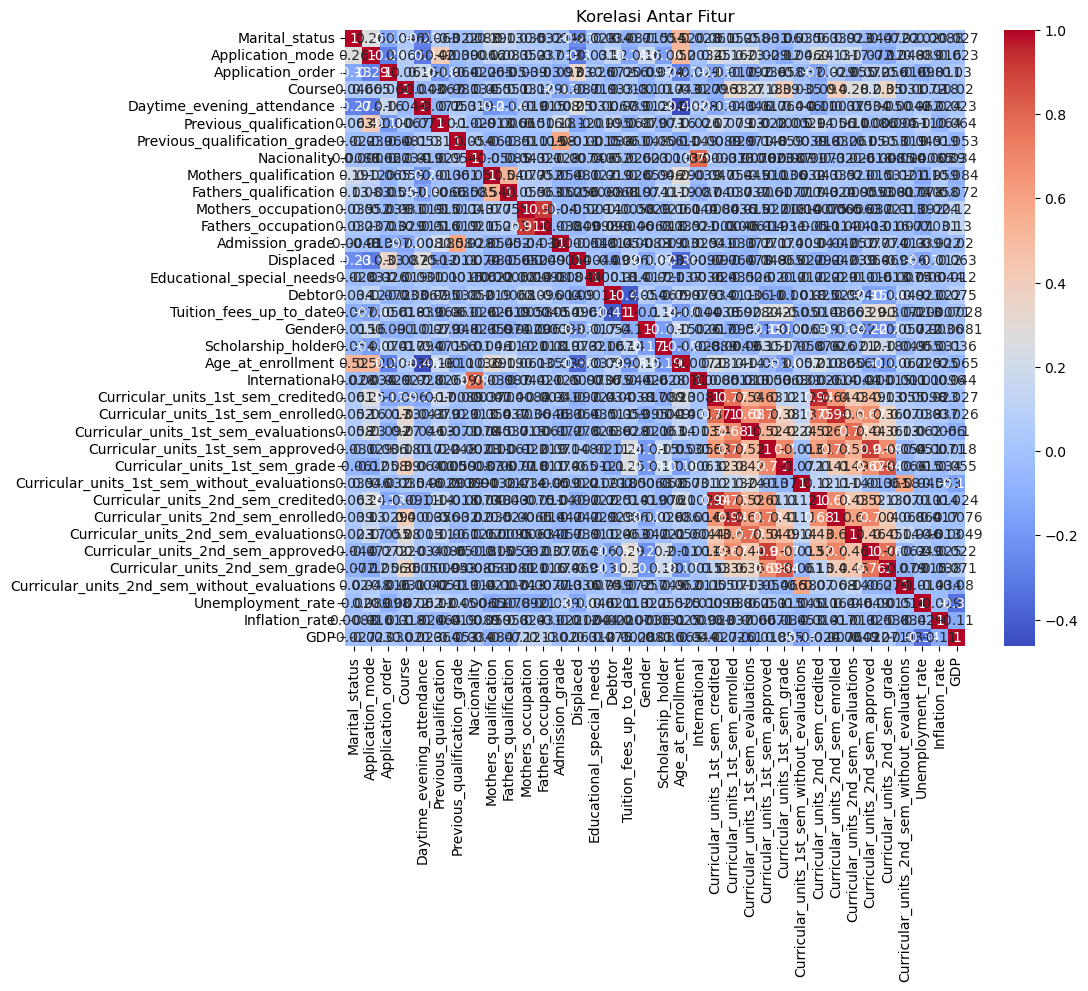

In [44]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Antar Fitur")
plt.show()

Tahap ini bertujuan untuk memahami struktur data, distribusi, serta hubungan antar variabel. Dari visualisasi terlihat bahwa beberapa fitur seperti nilai akademik dan absensi memiliki hubungan terhadap status dropout.

## Data Preparation / Preprocessing

In [45]:
df_clean = df.copy()

Encoding Data Kategorikal

In [46]:
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

Dilakukan encoding pada fitur kategorikal untuk mengubah data menjadi numerik agar dapat diproses oleh model machine learning.

Split Data

Memisahkan Fitur dan Target

In [47]:
X = df_clean.drop('Status', axis=1)
y = df_clean['Status']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Dataset dibagi menjadi data latih dan data uji dengan rasio 80:20 untuk mengevaluasi performa model.

Scaling

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling dilakukan untuk menyamakan skala data agar model dapat bekerja lebih optimal.

## Modeling

Training Model

In [57]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Prediksi

In [51]:
y_pred = model.predict(X_test)

Model Random Forest digunakan karena mampu menangani data dengan kompleksitas tinggi dan memberikan performa yang baik dalam klasifikasi.

## Evaluation

Accuracy

In [52]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7615819209039548


Model menghasilkan accuracy sebesar XX%, yang menunjukkan bahwa model cukup baik dalam memprediksi status dropout siswa.

Classification Report

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Dropout       0.85      0.77      0.81       316
    Enrolled       0.49      0.30      0.38       151
    Graduate       0.76      0.92      0.83       418

    accuracy                           0.76       885
   macro avg       0.70      0.67      0.67       885
weighted avg       0.75      0.76      0.75       885



Confusion Matrix

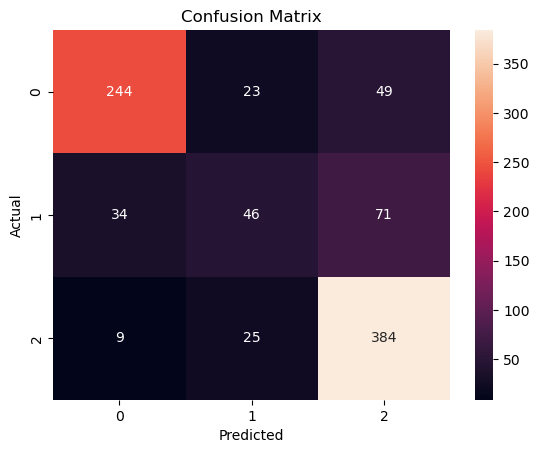

In [54]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion matrix menunjukkan bahwa model masih memiliki kesalahan dalam memprediksi beberapa siswa, terutama pada kelas dropout.

Feature Importance

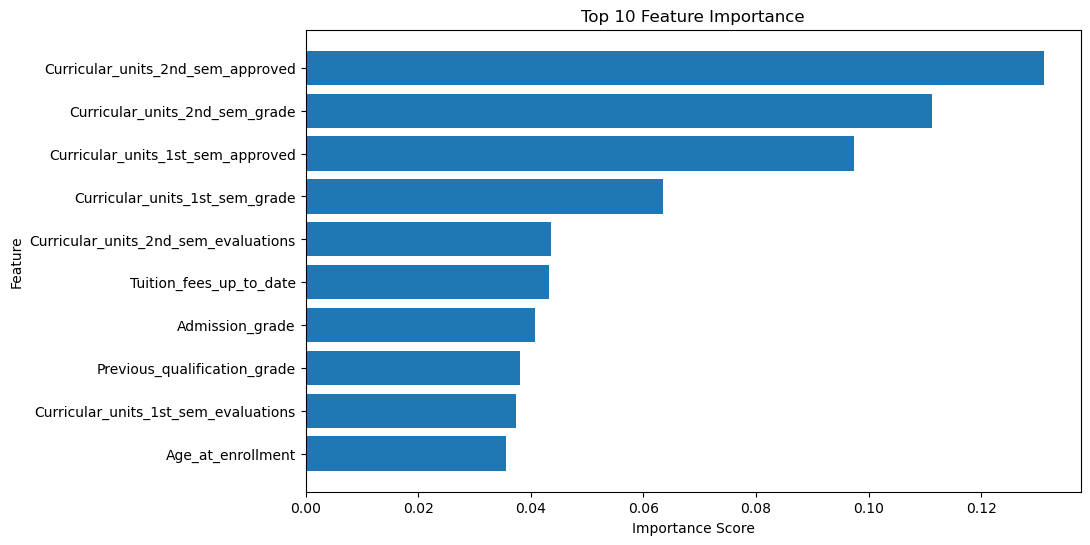

Model berhasil disimpan!


In [60]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

model_bundle = {
    "model": model,
    "scaler": scaler,
    "label_encoders": le_dict,
    "features": X.columns.tolist()
}

with open("model/model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("Model berhasil disimpan!")

Model dievaluasi menggunakan accuracy, classification report, dan confusion matrix.
Beberapa fitur yang memiliki pengaruh paling tinggi antara lain:

- **Nilai Akademik**  
  Siswa dengan nilai akademik rendah cenderung memiliki kemungkinan dropout yang lebih tinggi. Hal ini menunjukkan bahwa performa akademik merupakan indikator utama dalam keberhasilan siswa.

- **Tingkat Absensi**  
  Absensi yang rendah berkorelasi dengan meningkatnya risiko dropout. Siswa yang jarang hadir kemungkinan mengalami kesulitan mengikuti pembelajaran.

- **Faktor Sosial/Ekonomi (jika ada di dataset)**  
  Faktor eksternal seperti latar belakang ekonomi juga dapat mempengaruhi keberlanjutan pendidikan siswa.